### Explore A Jain's IEI pipeline
### Julian Moran
### 2026-02-09

In [1]:
import os

from dotenv import load_dotenv
from matplotlib.ticker import FuncFormatter
from matplotlib import pyplot as plt
from pathlib import Path
from typing import Tuple

import numpy as np
import polars as pl

# Env
pl.Config.set_tbl_rows(10)
load_dotenv("../.env")
INSTALL_PATH = os.environ["INSTALL_PATH"]

# Pipeline IO

Codebase at `/hpf/projects/CTrost/ajain/IEI_project/foldseek_AJ` 

1. DefenseFinder RefSeq IDs --> UniProt IDs
    - DefenseFinder: db of all bacterial genes implicated in antiphage systems
    - RefSeq bacterial accession IDs:   denote a bacterial immunoprotein; often begin with `WP`
    - UniProt access IDs:               denote a protein; e.g. `A0A7P0TAE1_HUMAN`

<br>

2. UniProt IDs --> Foldseek cluster ID

<br>

3. Foldseek cluster ID --> related human cluster ID

<br>

4. UniProt IDs --> UniprotKB annotations

<br>


# Questions

1. How does `01_RefSeq2Uniprot_mapping/` fit into the pipeline?
    - Are data in `01_RefSeq2Uniprot_mapping/` the output from pipeline step 2.?
    - Are data in `griid_gene_list/`, `gasdermin/`, `vipirin/`, `zorya/` prioritized subsets from `01_RefSeq2Uniprot_mapping/`?
    - If so, why are the subsets substantially larger than the original data?
    - `WP_063110969.1`, from `gasdermin/2025-07-26_gasdermin_annotated.xlsx`, is not in `data_local/01_RefSeq2Uniprot_mapping/2025-06-24_RefSeq2Uniprot_mapping.xlsx`

<br>

2. What is the relationship between each UniProt accession number and its corresponding cluster?
    - i.e. in datasets like `zorya/2025-07-27_zorya_annotated.tsv`?

<br>

3. Why do we see identical rows in the annotated data?
    - best to denote rows as `RefSeq_ID`,`UniProt_ID`,`FoldSeq_cluster`,`Similar_human_gene` 
    - e.g. in `zorya/2025-07-27_zorya_annotated.tsv`, see multiple rows for `WP_063192462.1`,`A0A142CZW3`,`A0A142CZW3`,`B4DLD8`

<br>

4. Human, Bacterial Domain Annotations ...
    - why is `Query_range` always a subset of the protein?
    - reading 1: `Query_range` is not an alignment subset because `Human_prot_domain_match` is in turn a subset of `Query_range` (same for `Target_range`, `Bacterial_prot_domain_match`)
    - reading 2: `*_range` annotations represent aligned sequences, and `*_domain` annotations represent something extraneous (e.g. sequence that matches documented bacterial domain) 
    - reading 2 is corroborated by our findings about the formula for `Overlap_ratio`

<br>


# Filtering criteria

1. Select for human proteins in same cluster as bacterial
    - `defense_system_cluster_id == cluster_id`
    - in annotated data, `defense_system_cluster_id` denotes the FoldSeek cluster that contains the query DefenseFinder protein
    - in annotated data, `cluster_id` denotes the most-similar target FoldSeek cluster containing a human protein 

<br>

2. Select for human proteins close in AA length to defense protein
    - col1: `Human_prot_total_length`
    - col2: `Bacterial_prot_total_length`
    - compute symmetric absolute percent difference (this appears to have been computed in `Overlap_ratio` col, albeit not symmetrically)
    - factor in percent overlap or percent match, here

<br>

3. Select for closest human genes that are in EAGLE definitive

<br>

# Plots

1. Heat map of e-values for strongly matching proteins

2. Histogram of AA length percent difference


In [2]:
# ============================================================
#                             Args
# ============================================================

args = {
    "data_file_foldseek_uniprot": f"{INSTALL_PATH}/data_local/02_FoldSeek_Results_w_Uniprot_matches/2025-07-26_batch_0_annotated.tsv",
    "data_file_GRIID": f"{INSTALL_PATH}/data_local/griid_gene_list/2025-07-30_data_filtered_for_griid_genes.tsv",
    "data_file_gasdermin": f"{INSTALL_PATH}/data_sync/gasdermin/2025-07-26_gasdermin_annotated.tsv",
    "data_file_vipirin": f"{INSTALL_PATH}/data_sync/viperin/2025-07-26_viperin_annotated.tsv",
    "data_file_zorya": f"{INSTALL_PATH}/data_local/zorya/2025-07-27_zorya_annotated.tsv",
    "out_path_plots": f"{INSTALL_PATH}/plots",
    "var_name_lengthError": "Protein_length_error",
    "threshold_lengthError": 0.05
}

In [3]:
# ============================================================
#                             In
# ============================================================

pl.Config.set_tbl_rows(10)

data_ann = {}
for key, path in args.items():
    if "data_file_" in key and not "foldseek" in key:
        data_key = key.replace("data_file_", "")
        data_ann[data_key] = pl.read_csv(
            args[key],
            has_header=True,
            separator="\t",
            schema_overrides={
                "duplicate_count": pl.Int64,
                "rank": pl.Int64,
                "evalue": pl.Float64,
                "cluFlag": pl.Int64,
                "fident": pl.Float64,
                "alnlen": pl.Int64,
                "mismatch": pl.Int64,
                "gapopen": pl.Float64,
                "qstart": pl.Int64,
                "qend": pl.Int64,
                "tstart": pl.Int64,
                "tend": pl.Int64,
                "evalue_foldseek": pl.Float64,
                "bits": pl.Int64,
                "Query_length": pl.Int64,
                "Human_prot_total_length": pl.Int64,
                "Human_domain_percentage": pl.Float64,
                "Query_percentage": pl.Float64,
                "Query_overlap_w_Human_protein": pl.Float64,
                "Target_length": pl.Int64,
                "Bacterial_prot_total_length": pl.Int64,
                "Bacterial_domain_percentage": pl.Float64,
                "Target_percentage": pl.Float64,
                "Target_overlap_w_Bacterial_protein": pl.Float64,
                "Bacterial_Human_Len_Ratio": pl.Float64,
                "Query_Target_Overlap_Length": pl.Float64,
                "Overlap_ratio": pl.Float64,
            },
            infer_schema_length=10000
        )

df_foldseek_uniprot = pl.read_csv(
    args["data_file_foldseek_uniprot"],
    separator="\t",
    has_header=True
)

df_foldseek_uniprot

accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,i64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,i64,f64
"""WP_001223208.1""","""MazEF""","""MazEF""","""Shigella dysenteriae,Escherich…","""GCF_003017995_NZ_CP027368_MazE…","""GCF_002156845.1_NZ_CP021339_05…","""GCF_019428585.1_NZ_CP080119_01…",671,6,"""A0A024L8H8""","""S3FMY0""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""nan..nan""",null,null,null,null,null,null,null,null,"""nan..nan""",null,83,null,null,null,null,null,null,null,null,null
"""WP_003414296.1""","""Cas""","""CAS_Class1-Subtype-III-A""","""Mycobacterium tuberculosis,Myc…","""GCF_014884645_NZ_CP043996_CAS_…","""GCF_002975475.1_NZ_CP027035_02…","""GCF_013010385.1_NZ_CP053092_02…",264,23,"""A0A045ICU9""","""A0A1I6JKI6""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""nan..nan""",null,null,null,null,null,null,null,null,"""nan..nan""",null,124,null,null,null,null,null,null,null,null,null
"""WP_002885155.1""","""AbiE""","""AbiE""","""Klebsiella sp. P1927,Klebsiell…","""GCF_022354545_NZ_CP055087_AbiE…","""GCF_022494255.1_NZ_CP058743_04…","""GCF_003286975.1_NZ_CP030172_04…",454,12,"""A0A060VEP4""","""J1I8N4""","""A0A6J2X4D6""","""Q5TF85""",0.02082,1,0.098,297,214,0,179,475,10,247,0.001215,42,"""unreviewed""","""Q5TF85_HUMAN""","""polynucleotide adenylyltransfe…","""TENT5A FAM46A hCG_401094""","""Homo sapiens (Human)""",null,"""hCG_401094""","""TENT5A""","""FAM46A""","""UP000005640: Chromosome 6""",null,null,"""poly(A) RNA polymerase activit…","""poly(A) RNA polymerase activit…","""GO:1990817""",null,null,null,"""IPR012937; TET5.;""","""PTHR12974; PRION-LIKE- Q/N-RIC…","""PF07984; NTP_transf_7; 1.;""",null,"""SM01153; DUF1693; 1.;""",null,"""179.0..475.0""",297,523,null,null,null,null,null,null,"""10.0..247.0""",238,305,null,null,null,null,null,null,0.583174,238,0.780328
"""WP_002885155.1""","""AbiE""","""AbiE""","""Klebsiella sp. P1927,Klebsiell…","""GCF_022354545_NZ_CP055087_AbiE…","""GCF_022494255.1_NZ_CP058743_04…","""GCF_003286975.1_NZ_CP030172_04…",454,12,"""A0A060VEP4""","""J1I8N4""","""G1SF99""","""Q5VWP2""",0.08138,1,0.094,295,265,0,49,343,10,302,0.0009699,39,"""reviewed""","""TET5C_HUMAN""","""Terminal nucleotidyltransferas…","""TENT5C FAM46C""","""Homo sapiens (Human)""",null,null,"""TENT5C""","""FAM46C""","""UP000005640: Chromosome 1""","""in utero embryonic development…","""centrosome [GO:0005813]; cytop…","""centrosome [GO:0005813]; cytop…","""poly(A) RNA polymerase activit…","""GO:0001701; GO:0003723; GO

In [4]:
# ============================================================
#                Clean, stack annotated data
# ============================================================

def remove_dup_rows(df: pl.DataFrame) -> int:
    df_dup_counted = (
        df.group_by(df.columns)
        .len()
    )
    dups_count = (
        df_dup_counted.filter(pl.col("len") > 1)
        .select((pl.col("len") - 1).sum())
        .item()
    )
    return df_dup_counted.drop("len"), dups_count


data_cleaned = {}
for data_key, df in data_ann.items():
    data_cleaned[data_key], dups_count = remove_dup_rows(df)
    print(f"Number of dup rows in {data_key}: {dups_count:,}")

    # Write out cleaned version
    if dups_count > 0:
        key = [k for k in args if data_key in k][0]
        out_path = Path(args[key].replace(".tsv", "_cleaned.tsv"))
        data_cleaned[data_key].write_csv(
            out_path,
            separator="\t",
            include_header=True
        )

df_cleaned = pl.concat(
    [df for df in data_cleaned.values()],
    how="diagonal"
)

print(f"Number of rows after cleaning, v-stacking: {len(df_cleaned):,}")
df_cleaned

Number of dup rows in GRIID: 0
Number of dup rows in gasdermin: 0
Number of dup rows in vipirin: 266
Number of dup rows in zorya: 40,578
Number of rows after cleaning, v-stacking: 321,575


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str
"""WP_050726769.1""","""Zorya""","""Zorya_TypeI""","""Vulgatibacter incomptus""","""GCF_001263175_NZ_CP012332_Zory…","""GCF_001263175.1_NZ_CP012332_02…","""GCF_001263175.1_NZ_CP012332_02…",1,202,"""A0A0K1PGI2""","""A0A355UP19""","""A0A0D0B8K2""","""Q4W5H1""",7.8290e-19,3,0.25,348,257,0.0,20,367,556,899,3.6030e-22,659,"""unreviewed""","""Q4W5H1_HUMAN""","""Uncharacterized protein SMARCA…","""SMARCA5""","""Homo sapiens (Human)""",null,null,"""SMARCA5""",null,null,"""chromatin remodeling [GO:00063…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; hydr…","""GO:0005524; GO:0005634; GO:000…","""cd18793; SF2_C_SNF; 1.;""","""3.40.50.10810:FF:000192; Chrom…","""3.40.50.300; P-loop containing…","""IPR014001; Helicase_ATP-bd.;""I…","""PTHR45623; CHROMODOMAIN-HELICA…","""PF00271; Helicase_C; 1.;""PF001…","""PS51192; HELICASE_ATP_BIND_1; …","""SM00490; HELICc; 1.;""",null,"""20.0..367.0""",348,367,"""220..367""",100.0,42.53,94.82,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…","""556.0..899.0""",344,920,"""441..626""",38.17,20.64,37.39,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",2.506812,344.0,0.9373297,"""Yes"""
"""WP_001063091.1""","""RM""","""RM_Type_II""","""Escherichia coli""","""GCF_016903335_NZ_CP069890_RM_T…","""GCF_004564035.1_NZ_CP035498_04…","""GCF_002310635.1_NZ_CP023388_00…",56,147,"""A0A454AAW4""","""A0A2N1TG36""","""C4MBQ2""","""B2R6Q4""",6.4380e-8,1,0.11,279,182,0.0,170,448,290,495,1.221,5,"""unreviewed""","""B2R6Q4_HUMAN""","""Tyrosine-protein kinase (EC 2.…","""CSK hCG_40804""","""Homo sapiens (Human)""",null,"""hCG_40804""","""CSK""",null,null,"""adherens junction organization…","""cell-cell junction [GO:0005911…","""cell-cell junction [GO:0005911…","""ATP binding [GO:0005524]; non-…","""GO:0004715; GO:0005524; GO:000…","""cd05082; PTKc_Csk; 1.;""cd09937…","""1.10.510.10:FF:000272; Tyrosin…","""3.30.200.20; Phosphorylase Kin…","""IPR035027; Csk-like_SH2.;""IPR0…","""PTHR24418; TYROSINE-PROTEIN KI…","""PF07714; PK_Tyr_Ser-Thr; 1.;""P…","""PS00107; PROTEIN_KINASE_ATP; 1…","""SM00252; SH2; 1.;""SM00326; SH3…","""NP_001120662.1; NM_001127190.2…","""170.0..448.0""",279,450,"""195..449""",99.61,91.04,62.0,"""['Protein kinase']""","""['ECO:0000259|PROSITE:PS50011'…","""290.0..495.0""",206,986,null,null,null,null,null,null,2.191111,206.0,0.457778,"""Yes"""
"""WP_021263740.1""","""Zorya""","""Zorya_TypeI""","""Pseudomonas aeruginosa""","""GCF_003204335_NZ_CP029745_Zory…","""GCF_018279285.1_NZ_CP061779_05…","""GCF_003204335.1_NZ_CP029745_01…",10,193,"""A6VE70""","""A0A355UP19""","""A0A6P8QA92""","""A0A590UJK0""",7

In [5]:
# ============================================================
#                     Filter annotated data
# ============================================================

def filter_data(
        df: pl.DataFrame,
) -> pl.DataFrame:

    df = df.filter(
        (pl.col("defense_system_cluster_id") == pl.col("cluster_id")) &
        (pl.col("Organism") == "Homo sapiens (Human)")
    )
    print(f"N rows after filtering: {len(df)}")

    return df

# What are the species annotations for closest match?
print("Unique values for col `Species` before filtering:")
print(df_cleaned["Organism"].unique())

df_filtered = filter_data(
    df=df_cleaned,
    var_length_error=args["var_name_lengthError"]
)
df_filtered

Unique values for col `Species` before filtering:
shape: (2,)
Series: 'Organism' [str]
[
	"Homo sapiens (Human)"
	null
]
N rows after filtering: 904


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str
"""WP_035566027.1""","""Zorya""","""Zorya_TypeI""","""Halomonas sp. KO116""","""GCF_000734975_NZ_CP011052_Zory…","""GCF_000734975.2_NZ_CP011052_02…","""GCF_000734975.2_NZ_CP011052_02…",1,202,"""A0A0D5M5G2""","""A0A355UP19""","""A0A355UP19""","""Q9H4L7""",0.0,1,0.188,696,536,0.0,366,1026,315,1010,3.7380e-28,806,"""reviewed""","""SMRCD_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAD1 KIAA1122""","""Homo sapiens (Human)""",null,null,"""SMARCAD1""","""KIAA1122""","""UP000005640: Chromosome 4""","""chromatin remodeling [GO:00063…","""chromatin [GO:0000785]; hetero…","""chromatin [GO:0000785]; hetero…","""ATP binding [GO:0005524]; ATP …","""GO:0000018; GO:0000729; GO:000…","""cd17998; DEXHc_SMARCAD1; 1.;""c…","""3.40.50.10810:FF:000014; SWI/S…","""3.40.50.300; P-loop containing…","""IPR003892; CUE.;""IPR014001; He…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF00271; Helicase_C; 1.;""PF001…","""PS51140; CUE; 2.;""PS51192; HEL…","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001121901.1; NM_001128429.3…","""366.0..1026.0""",661,1026,"""509..677""",100.0,25.57,64.42,"""['Helicase ATP-binding']""","""['ECO:0000255|PROSITE-ProRule:…","""315.0..1010.0""",696,1010,"""479..686""",100.0,29.89,68.91,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",0.984405,661.0,0.654455,"""No"""
"""WP_025297649.1""","""Zorya""","""Zorya_TypeI""","""Pseudomonas aeruginosa""","""GCF_000981825_NZ_CP011317_Zory…","""GCF_009662315.1_NZ_CP045739_06…","""GCF_023093935.1_NZ_CP095770_06…",7,196,"""A0A2U2XIN6""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.192,637,507,0.0,309,936,377,1013,1.3100e-31,820,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""309.0..936.0""",628,1014,"""765..934""",100.0,27.07,61.93,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…","""377.0..1013.0""",637,1028,"""480..688""",100.0,32.81,61.96,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",1.013807,628.0,0.619329,"""No"""
"""WP_004883274.1""","""Cas""","""CAS_Class1-Subtype-IV-A""","""Klebsiella pneumoniae,Klebsiel…","""GCF_013826045_NZ_CP057314_CAS_…","""GCF

In [9]:
# ============================================================
#                        Compute new metrics
# ============================================================

def add_annotations(
        df: pl.DataFrame,
        var_length_error: str,
) -> pl.DataFrame:

    df = df.with_columns(
        ((pl.col("Bacterial_prot_total_length") / pl.col("Human_prot_total_length")) - 1)
        .abs()
        .alias(var_length_error)
    ).filter(
        (pl.col(var_length_error).is_not_null() & pl.col(var_length_error).is_not_nan())
    )
    print(f"N of rows after filtering out nulls for extra metrics: {len(df):,}")
    return df

df_extra_metrics = add_annotations(
    df=df_filtered,
    var_length_error=args["var_name_lengthError"]
)

df_extra_metrics

N of rows after filtering out nulls for extra metrics: 868


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene,Protein_length_error
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str,f64
"""WP_035566027.1""","""Zorya""","""Zorya_TypeI""","""Halomonas sp. KO116""","""GCF_000734975_NZ_CP011052_Zory…","""GCF_000734975.2_NZ_CP011052_02…","""GCF_000734975.2_NZ_CP011052_02…",1,202,"""A0A0D5M5G2""","""A0A355UP19""","""A0A355UP19""","""Q9H4L7""",0.0,1,0.188,696,536,0.0,366,1026,315,1010,3.7380e-28,806,"""reviewed""","""SMRCD_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAD1 KIAA1122""","""Homo sapiens (Human)""",null,null,"""SMARCAD1""","""KIAA1122""","""UP000005640: Chromosome 4""","""chromatin remodeling [GO:00063…","""chromatin [GO:0000785]; hetero…","""chromatin [GO:0000785]; hetero…","""ATP binding [GO:0005524]; ATP …","""GO:0000018; GO:0000729; GO:000…","""cd17998; DEXHc_SMARCAD1; 1.;""c…","""3.40.50.10810:FF:000014; SWI/S…","""3.40.50.300; P-loop containing…","""IPR003892; CUE.;""IPR014001; He…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF00271; Helicase_C; 1.;""PF001…","""PS51140; CUE; 2.;""PS51192; HEL…","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001121901.1; NM_001128429.3…","""366.0..1026.0""",661,1026,"""509..677""",100.0,25.57,64.42,"""['Helicase ATP-binding']""","""['ECO:0000255|PROSITE-ProRule:…","""315.0..1010.0""",696,1010,"""479..686""",100.0,29.89,68.91,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",0.984405,661.0,0.654455,"""No""",0.015595
"""WP_025297649.1""","""Zorya""","""Zorya_TypeI""","""Pseudomonas aeruginosa""","""GCF_000981825_NZ_CP011317_Zory…","""GCF_009662315.1_NZ_CP045739_06…","""GCF_023093935.1_NZ_CP095770_06…",7,196,"""A0A2U2XIN6""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.192,637,507,0.0,309,936,377,1013,1.3100e-31,820,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""309.0..936.0""",628,1014,"""765..934""",100.0,27.07,61.93,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…","""377.0..1013.0""",637,1028,"""480..688""",100.0,32.81,61.96,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",1.013807,628.0,0.619329,"""No""",0.013807
"""WP_004883274.1""","""Cas""","""CAS_Class1-Subtype-IV-A""","""Klebsiella pneumoniae,Klebsiel…"

Protein_length_error max: 0.52
Protein_length_error min: 0.0


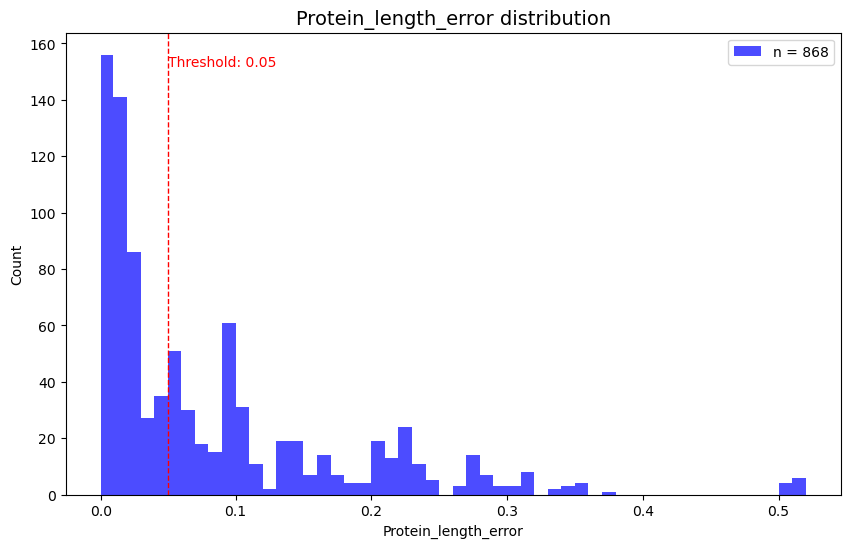

In [10]:
# ============================================================
#                  Plot: Protein length error
# ============================================================

# PLot histogram of `Protein_length_error`
def out_plot(
        figure: plt.Figure,
        out_path: str,
        svg: bool = True,
        png_dpi: int = 1080
) -> None:
    out_path = Path(out_path)
    if svg:
        figure.savefig(out_path.with_suffix(".svg"))
    if png_dpi:
        figure.savefig(out_path.with_suffix(".png"), dpi=png_dpi)
    return None

def plot_hist(
        df: pl.DataFrame,
        col_name: str,
        colour: str = "blue",
        alpha: float = 0.7,
        bin_width: float = 10.0,
        tick_interval: float = 0.1,
        exclude_zeros: bool = False,
        last_bin_leftSide: float = None,
        title: str = "Var distribution",
        title_fontSize: int = 14,
        axis_label_fontSize: int = 10,
        xlabel: str = "Var",
        ylabel: str = "Count",
        threshold: float = None,
        threshold_ann: str = None,
        dims: Tuple[int, int] = (10, 6),
        out_path: str = None
) -> None:
    
    var = df[col_name].to_numpy().astype(float)
    min, max = var.min(), var.max()
    print(f"{col_name} max: {round(max, 2):,}")
    print(f"{col_name} min: {round(min, 2):,}")
    fig, ax = plt.subplots(figsize=dims)

    if exclude_zeros:
        var = var[var != 0]
        min = var.min()
        print(f"Trimmed min {col_name}: {min}")
        
    if last_bin_leftSide is not None:
        var = np.where(
            var > last_bin_leftSide,
            last_bin_leftSide + bin_width,
            var
        )
        max = var.max()
        def _fmt(x, pos):
            if np.isclose(x, max - bin_width):
                return f"{int(last_bin_leftSide):,}+"
            return f"{int(x):,}"
        
        print(f"Trimmed max {col_name}: {max}")
    
    else:
        def _fmt(x, pos):
            return f"{round(x, 2):,}"
            
    xticks = np.arange(0, max, tick_interval)
    xticks[0] = min

    edges = np.arange(0, max + bin_width, bin_width)
    edges[0] = min

    ax.hist(var, bins=edges, color=colour, alpha=alpha, label=f"n = {var.size:,}")
    ax.legend()
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.xaxis.set_major_formatter(FuncFormatter(_fmt))
    ax.set_xticks(xticks)
    ax.set_xlabel(xlabel, fontsize=axis_label_fontSize)
    ax.set_ylabel(ylabel, fontsize=axis_label_fontSize)
    ax.set_title(title, fontsize=title_fontSize)

    if threshold is not None:
        ax.axvline(x=threshold, color="red", linestyle="--", linewidth=1)
        if threshold_ann is None:
            threshold_ann = f"Threshold: {threshold}"
        ax.text(threshold, ax.get_ylim()[1]*0.95, threshold_ann, color="red", ha="left", va="top", fontsize=axis_label_fontSize)

    if out_path is not None:
        out_plot(figure=fig, out_path=out_path, svg=True, png_dpi=1080)

    plt.show()

plot_hist(
    df=df_extra_metrics,
    col_name=args["var_name_lengthError"],
    tick_interval=0.1,
    bin_width=0.01,
    title=f"{args['var_name_lengthError']} distribution",
    xlabel=args["var_name_lengthError"],
    out_path=f"{args['out_path_plots']}/hist_{args['var_name_lengthError']}",
    threshold=args["threshold_lengthError"]
)

# Overlap_ratio

From studying pattern the following dataset:
```
Query_length	Human_prot_total_length	Target_length	Bacterial_prot_total_length	Overlap_ratio
661	1026	696	1010	0.654455446
628	1014	637	1028	0.619329389
663	1014	620	971 0.638516993
546	1026	516	999	0.516516517
365	369	341	355	0.96056338
```

<br>

Formula for `Overlap_ratio`:
```Python
pl.col("Overlap_ratio") = (
    min([pl.col("Query_length"), pl.col("Target_length")]) 
    / min([pl.col("Human_prot_total_length"), pl.col("Bacterial_prot_total_length")])
)
```



In [11]:
# ============================================================
#                   Filter by extra metrics
# ============================================================

def filter_extra_metrics(
        df: pl.DataFrame,
        var_length_error: str,
        threshold_length_error: float
) -> pl.DataFrame:
    
    df = df.filter(
        pl.col(var_length_error) <= threshold_length_error
    )

    print(f"N rows after filtering by extra metrics: {len(df)}")
    return df

df_filtered_extra = filter_extra_metrics(
    df=df_extra_metrics,
    var_length_error=args["var_name_lengthError"],
    threshold_length_error=args["threshold_lengthError"]
)

df_filtered_extra

N rows after filtering by extra metrics: 445


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene,Protein_length_error
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str,f64
"""WP_035566027.1""","""Zorya""","""Zorya_TypeI""","""Halomonas sp. KO116""","""GCF_000734975_NZ_CP011052_Zory…","""GCF_000734975.2_NZ_CP011052_02…","""GCF_000734975.2_NZ_CP011052_02…",1,202,"""A0A0D5M5G2""","""A0A355UP19""","""A0A355UP19""","""Q9H4L7""",0.0,1,0.188,696,536,0.0,366,1026,315,1010,3.7380e-28,806,"""reviewed""","""SMRCD_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAD1 KIAA1122""","""Homo sapiens (Human)""",null,null,"""SMARCAD1""","""KIAA1122""","""UP000005640: Chromosome 4""","""chromatin remodeling [GO:00063…","""chromatin [GO:0000785]; hetero…","""chromatin [GO:0000785]; hetero…","""ATP binding [GO:0005524]; ATP …","""GO:0000018; GO:0000729; GO:000…","""cd17998; DEXHc_SMARCAD1; 1.;""c…","""3.40.50.10810:FF:000014; SWI/S…","""3.40.50.300; P-loop containing…","""IPR003892; CUE.;""IPR014001; He…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF00271; Helicase_C; 1.;""PF001…","""PS51140; CUE; 2.;""PS51192; HEL…","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001121901.1; NM_001128429.3…","""366.0..1026.0""",661,1026,"""509..677""",100.0,25.57,64.42,"""['Helicase ATP-binding']""","""['ECO:0000255|PROSITE-ProRule:…","""315.0..1010.0""",696,1010,"""479..686""",100.0,29.89,68.91,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",0.984405,661.0,0.654455,"""No""",0.015595
"""WP_025297649.1""","""Zorya""","""Zorya_TypeI""","""Pseudomonas aeruginosa""","""GCF_000981825_NZ_CP011317_Zory…","""GCF_009662315.1_NZ_CP045739_06…","""GCF_023093935.1_NZ_CP095770_06…",7,196,"""A0A2U2XIN6""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.192,637,507,0.0,309,936,377,1013,1.3100e-31,820,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""309.0..936.0""",628,1014,"""765..934""",100.0,27.07,61.93,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…","""377.0..1013.0""",637,1028,"""480..688""",100.0,32.81,61.96,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",1.013807,628.0,0.619329,"""No""",0.013807
"""WP_174757529.1""","""Zorya""","""Zorya_TypeI""","""Azospirillum oryzae""","""GCF_013347285_NZ

# To do

1. Filter by match overlap
- generate hist for match overlap


<br>

2. Filter by e-value
- generate heat map for e-value